# Pooled ENT versus NENT misfolding probability

This notebook uses the plotting format from `Plot_misfolding_propensity_Nature_style.ipynb`:
4.0 × 3.5 inch figure, Arial 8 pt text, grayscale violins, deterministic jittered
protein observations, and horizontal median lines.

Data are read from the current `minor5_misfolding_4groups.xlsx` workbook:
ENT = SC_ENT + NSC_ENT; NENT = SC_NENT + NSC_NENT. Each protein contributes one value.
The x-axis categories are **Proteins with native NCLEs** and
**Proteins without native NCLEs**, wrapped over two lines for readability.

Outputs are a vector PDF and a 600 dpi PNG, saved beside the source workbook.
The figure follows the reference's median-only overlay; it adds no confidence
intervals or statistical-test annotation. The group counts and medians are shown below.


### 1. Apply the original plotting style

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

# ----------------------------
# Nature-like style (single place)
# ----------------------------
BASE_FONTSIZE = 8
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": BASE_FONTSIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "axes.labelsize": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.linewidth": 0.8,
    "axes.spines.right": False,
    "axes.spines.top": False,

    "xtick.labelsize": BASE_FONTSIZE,
    "ytick.labelsize": BASE_FONTSIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 0,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,

    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

### 2. Load and validate the pooled protein groups

In [2]:
from pathlib import Path
import hashlib
import pandas as pd
from matplotlib import font_manager
from IPython.display import display

DATA_DIR = Path.cwd()
SOURCE_FILE = DATA_DIR / 'minor5_misfolding_4groups.xlsx'
SOURCE_SHEET = 'Replaced_play_expanded'
OUTPUT_STEM = 'Nature_style_pooled_ENT_NENT_misfolding_propensity_violin'
assert SOURCE_FILE.is_file(), 'Run this notebook from the minor5_analysis directory.'
assert font_manager.findfont('Arial', fallback_to_default=False)
source_sha256 = hashlib.sha256(SOURCE_FILE.read_bytes()).hexdigest()

raw = pd.read_excel(SOURCE_FILE, sheet_name=SOURCE_SHEET, header=1)
group_map = {'SC_ENT': 'ENT', 'NSC_ENT': 'ENT',
             'SC_NENT': 'NENT', 'NSC_NENT': 'NENT'}
proteins = raw.loc[raw['Label'].isin(group_map),
                   ['Label', 'SC-ENT', 'misfolding', 'Native prob']].copy()
proteins = proteins.rename(columns={'SC-ENT': 'Uniprot'})
proteins['Group'] = proteins['Label'].map(group_map)
proteins['misfolding_probability'] = pd.to_numeric(proteins['misfolding'], errors='coerce')
native_probability = pd.to_numeric(proteins['Native prob'], errors='coerce')
assert proteins['Uniprot'].notna().all() and proteins['Uniprot'].is_unique
assert proteins['misfolding_probability'].notna().all()
assert proteins['misfolding_probability'].between(0, 1).all()
assert native_probability.notna().all()
np.testing.assert_allclose(proteins['misfolding_probability'],
                          1 - native_probability, atol=1e-12, rtol=0)
assert proteins['Label'].value_counts().reindex(group_map).tolist() == [24, 24, 24, 24]

misfolding_ent = proteins.loc[proteins['Group'].eq('ENT'), 'misfolding_probability'].to_numpy(float)
misfolding_nent = proteins.loc[proteins['Group'].eq('NENT'), 'misfolding_probability'].to_numpy(float)
assert len(misfolding_ent) == len(misfolding_nent) == 48
summary = proteins.groupby('Group')['misfolding_probability'].agg(N='size', Median='median').reindex(['ENT', 'NENT'])
display(summary)
print(f'Source: {SOURCE_FILE.resolve()} | {SOURCE_SHEET} | header row 2')
print(f'Source SHA-256: {source_sha256}')


,N,Median
Group,,
ENT,48,0.3105
NENT,48,0.1300


Source: /Users/qvv/Library/CloudStorage/OneDrive-ThePennsylvaniaStateUniversity/Research_Cloud/Projects/aging/manuscript/v1.7_JACS/R1/minor5_analysis/minor5_misfolding_4groups.xlsx | Replaced_play_expanded | header row 2
Source SHA-256: 275d6c080695a9851885bc220e9e82e072e713ab5461bf13f413ccfbbe07a52e


### 3. Plot and export using the reference format

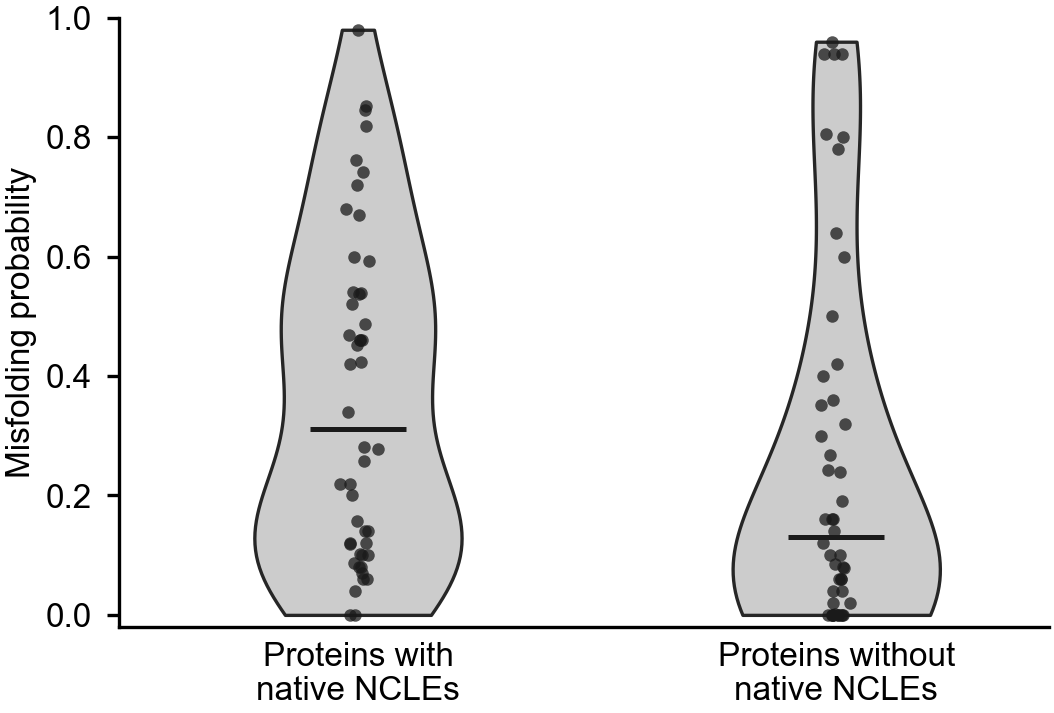

Saved: Nature_style_pooled_ENT_NENT_misfolding_propensity_violin.pdf and Nature_style_pooled_ENT_NENT_misfolding_propensity_violin.png


In [3]:
data = [misfolding_ent, misfolding_nent]
category_labels = [
    "Proteins with native NCLEs",
    "Proteins without native NCLEs",
]
labels = [
    "Proteins with\nnative NCLEs",
    "Proteins without\nnative NCLEs",
]
assert [' '.join(label.split()) for label in labels] == category_labels

positions = np.array([0.9, 2.7])



# ----------------------------
# Plot (single-column width)
# ----------------------------
fig, ax = plt.subplots(figsize=(4.0, 3.5))  # single column width

vp = ax.violinplot(
    data, positions=positions, widths=0.78,
    showmeans=False, showmedians=False, showextrema=False
)

# Grayscale styling (Nature friendly)
for body in vp["bodies"]:
    body.set_facecolor("0.80")    # light gray
    body.set_edgecolor("0.15")    # dark edge
    body.set_linewidth(0.8)
    body.set_alpha(1.0)

# Median lines
for x, d in zip(positions, data):
    med = np.percentile(d, 50)
    ax.plot([x - 0.18, x + 0.18], [med, med], lw=1.2, color="0.10", solid_capstyle="butt")

# Jittered points
rng = np.random.default_rng(42)
for x, d in zip(positions, data):
    jitter = rng.normal(0, 0.035, size=len(d))
    ax.plot(np.full(len(d), x) + jitter, d, "o",
            ms=3.0, alpha=0.75, mec="none", mfc="0.10")

# Labels and ticks
ax.set_ylabel("Misfolding probability", labelpad=2)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=0, ha="center", linespacing=1.15)
ax.set_xlim(0.0, 3.5)

# Y range and ticks (adjust if you want a tighter top)
ax.set_ylim(-0.02, 1.00)
ax.set_yticks(np.arange(0.0, 1.01, 0.2))
ax.tick_params(top=False, right=False)

plt.subplots_adjust(bottom=0.30)

# Save both vector and raster
fig.savefig(DATA_DIR / f"{OUTPUT_STEM}.pdf")          # vector for Nature
fig.savefig(DATA_DIR / f"{OUTPUT_STEM}.png", dpi=600) # raster preview

plt.show()

# Verify the displayed observations and labels, then release the figure.
assert [len(line.get_ydata()) for line in ax.lines] == [2, 2, 48, 48]
np.testing.assert_allclose(ax.lines[0].get_ydata(), np.median(misfolding_ent))
np.testing.assert_allclose(ax.lines[1].get_ydata(), np.median(misfolding_nent))
assert [tick.get_text() for tick in ax.get_xticklabels()] == labels
assert source_sha256 == hashlib.sha256(SOURCE_FILE.read_bytes()).hexdigest()
plt.close(fig)
print(f'Saved: {OUTPUT_STEM}.pdf and {OUTPUT_STEM}.png')